In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
from metrics.graph import *
from utils.results import *
from pipeline.pipelineR import *

from algorithms.benchmark import run_hc, run_ea
from algorithms.runtime import measure_call, bytes_to_mb
from utils.plotting import *
from utils.data import load_csv_with_attrs

In [18]:
# JPMF Data

# base_dir = "data/experiments/RQ1/jpmf_grid/"
base_dir = "data/experiments/RQ1/binary_grid/"
df_num = 20
df = load_csv_with_attrs(base_dir + f"Data_Graph_{df_num}.csv")
metadata = pd.read_csv(base_dir + f"Metadata_Graph_{df_num}.csv")
true_cpdag = dag_to_cpdag(create_graph(metadata))


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

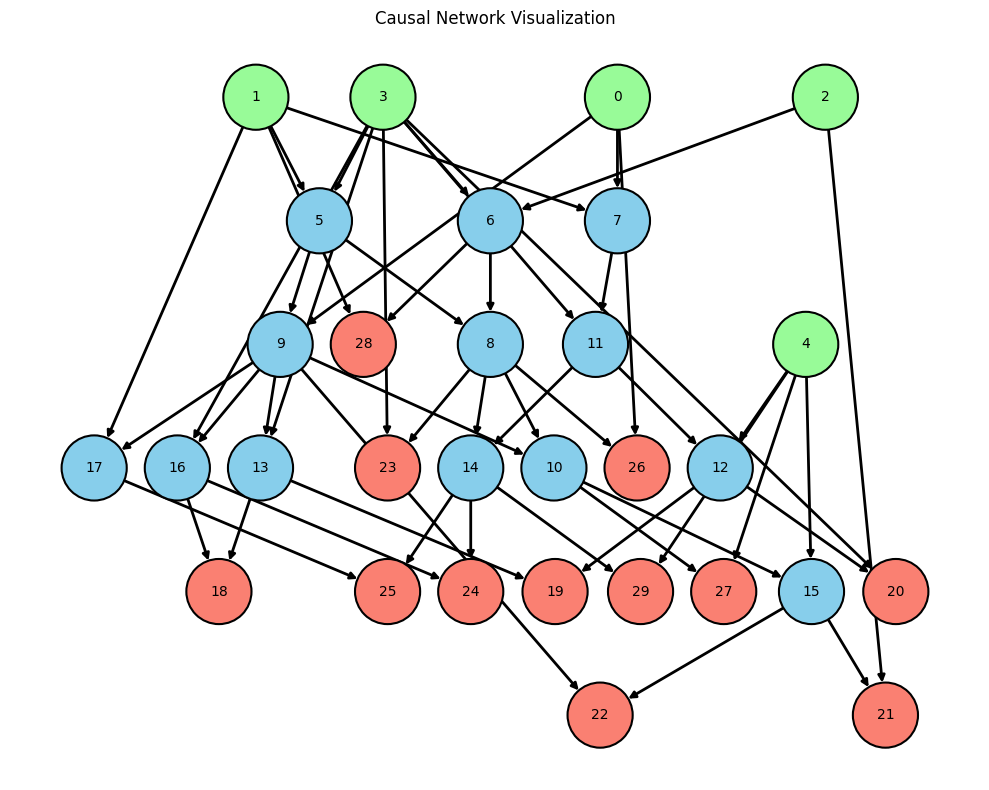

In [19]:
visualize_graph(true_cpdag)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'True CPDAG'}>)

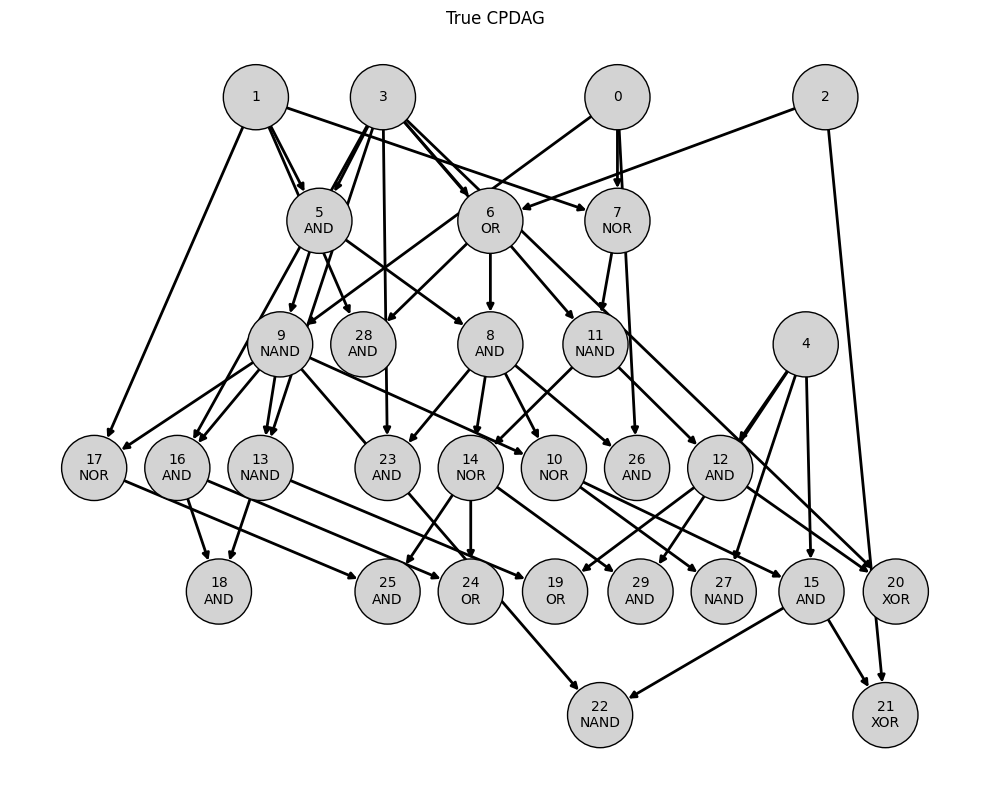

In [20]:
visualize_network_labels(metadata=metadata, title="True CPDAG")

In [21]:
# df.attrs

In [22]:

hc = partial(run_hc, restarts=1)
(learned_cpdag, bic), rt = measure_call(
        hc,
        df,
        tracemalloc=True,   # set True if you want Python alloc peak (extra overhead)
        gc_collect=False,
    )

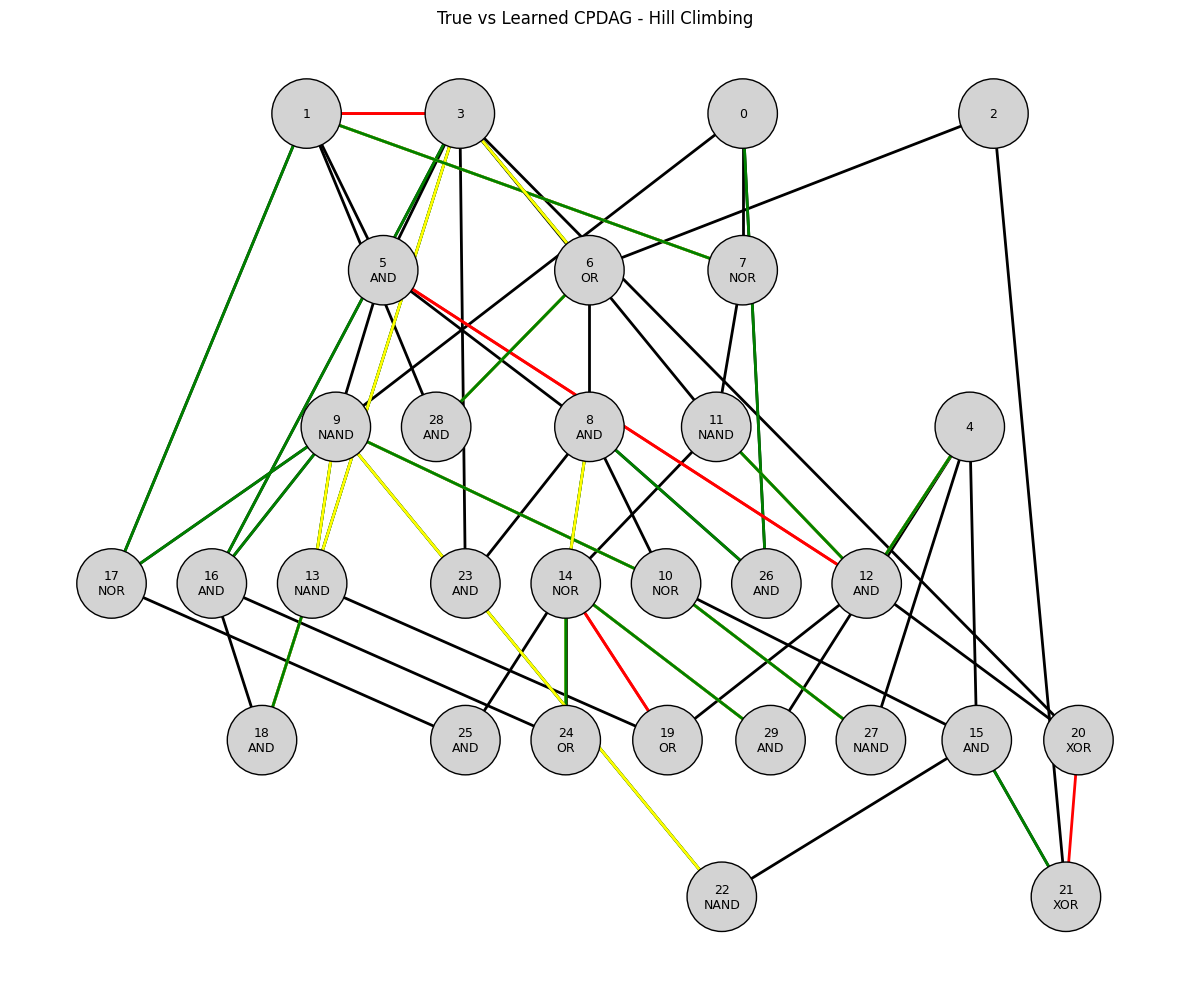

In [23]:
from utils.plotting import *
# visualize_dag(learned_cpdag, title=f"Hill Climbing Learned CPDAG")
fig, metrics = compare_dags_with_labels(true_cpdag, learned_cpdag, metadata=metadata, title="True vs Learned CPDAG - Hill Climbing")

In [24]:
eval_metrics = {}
eval_metrics = compare_cpdags(true_graph=true_cpdag, learned_graph=learned_cpdag)
eval_metrics.update(evaluate_colliders(metadata_df=metadata, learned_graph=learned_cpdag))
pd.DataFrame([eval_metrics])

,n_nodes,n_pairs,SHD [CPDAG],SHD [Skeleton],Type Confusions [Adjacency],n_true [Adjacency],n_pred [Adjacency],TP [Adjacency],FP [Adjacency],FN [Adjacency],...,FN (Missing Colliders ),TP (Synergistic Colliders Found),FN (Missing Synergistic Colliders),Precision (Collider),Recall (Collider),F1 (Collider),Recall (Synergy),TP (Pairwise Colliders Found),FN (Missing Pairwise Colliders),Recall (Pairwise)
0,30.0,435.0,47.0,33.0,14.0,50.0,25.0,21.0,4.0,29.0,...,22,0,2,0.75,0.12,0.206897,0.0,3,20,0.130435


In [25]:
print(f"Wall Time : {rt.wall_time_s:.4f} seconds")
print(f"CPU Time  : {rt.cpu_time_s:.4f} seconds")
print(f"Memory Allocated : {bytes_to_mb(rt.tracemalloc_peak_bytes):.4f} MB")
print(f"RSS Delta : {bytes_to_mb(rt.rss_delta_bytes):.4f} MB")

Wall Time : 5.4828 seconds
CPU Time  : 5.4375 seconds
Memory Allocated : 1.5960 MB
RSS Delta : 0.8008 MB


### EA

In [ ]:
ea_greedy = partial(run_ea, population_size=20, generations=20, final_greedy=True, informed_ratio=1, n_jobs=10)
(learned_cpdag, bic), rt = measure_call(
            ea_greedy,
            df,
            tracemalloc=True,   # set True if you want Python alloc peak (extra overhead)
            gc_collect=False,
        )

: 

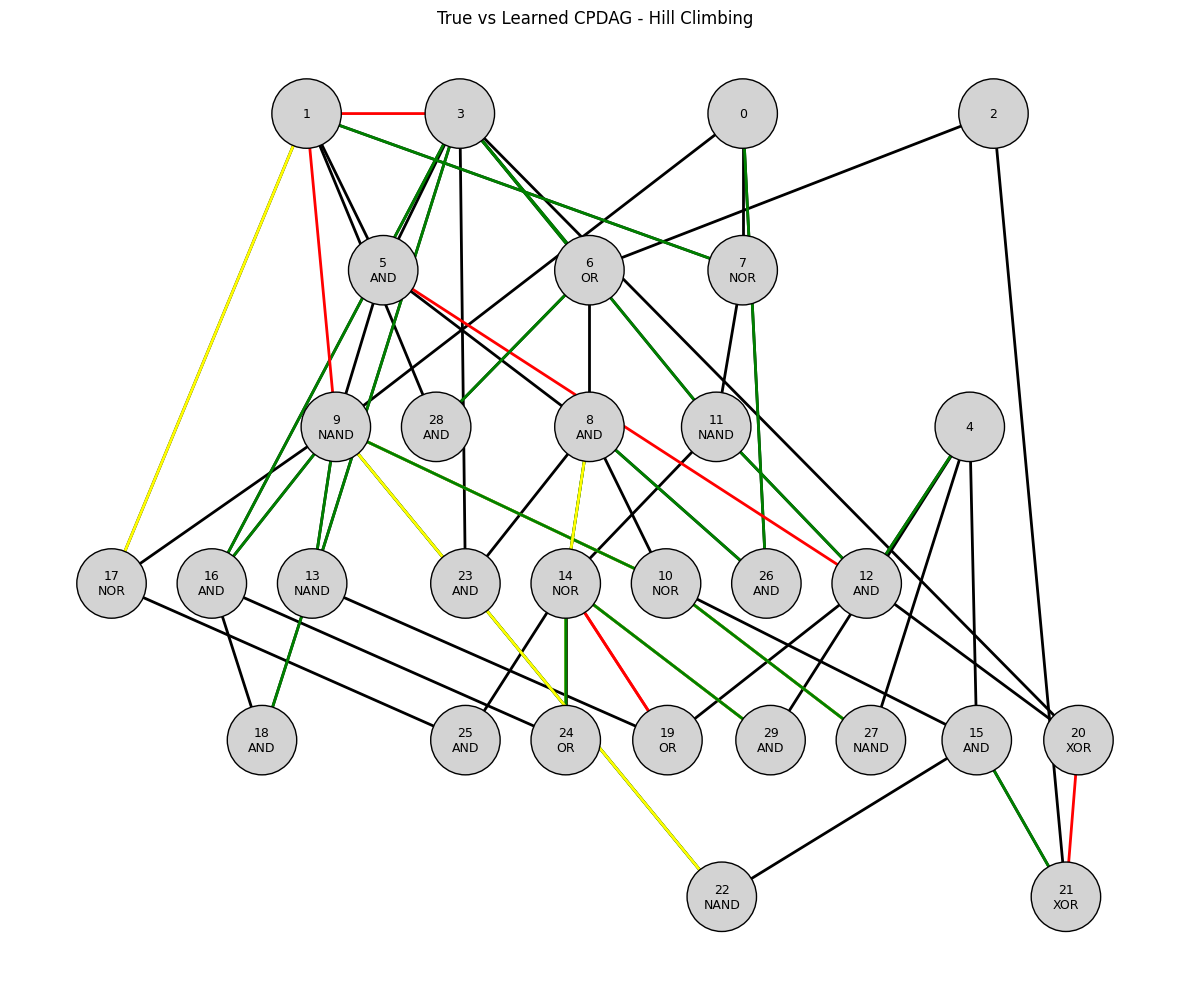

In [27]:
fig, metrics = compare_dags_with_labels(true_cpdag, learned_cpdag, metadata=metadata, title="True vs Learned CPDAG - Hill Climbing")

In [28]:
print(f"Wall Time : {rt.wall_time_s:.4f} seconds")
print(f"CPU Time  : {rt.cpu_time_s:.4f} seconds")
print(f"Memory Allocated : {bytes_to_mb(rt.tracemalloc_peak_bytes):.4f} MB")
# print(f"RSS Delta : {bytes_to_mb(rt.rss_delta_bytes):.4f} MB")

Wall Time : 9.6248 seconds
CPU Time  : 9.2969 seconds
Memory Allocated : 1.8806 MB


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'EA Learned CPDAG'}>)

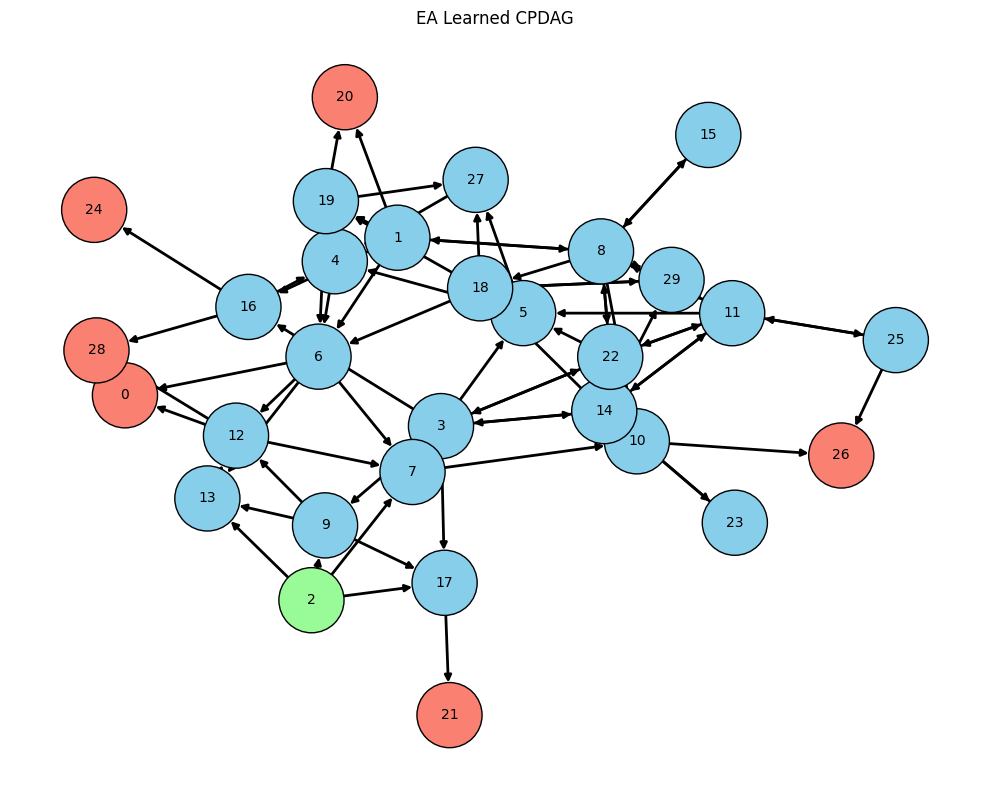

In [16]:
visualize_dag(learned_cpdag, title=f"EA Learned CPDAG")

In [17]:
eval_metrics = {}
eval_metrics = compare_cpdags(true_graph=true_cpdag, learned_graph=learned_cpdag)
eval_metrics.update(evaluate_colliders(metadata_df=metadata, learned_dag=learned_cpdag))
pd.DataFrame([eval_metrics])

TypeError: evaluate_colliders() got an unexpected keyword argument 'learned_dag'